In [3]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path
from zipfile import ZipFile
import re
import xml.etree.ElementTree as ET
plt.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style('white')
COMMON_MINIMUM_BP = 5000

In [4]:
def _xml_local_name(tag):
    return tag.rsplit('}', 1)[-1]


def _excel_column_index(cell_reference):
    letters = re.match(r'[A-Z]+', cell_reference).group(0)
    value = 0
    for letter in letters:
        value = value * 26 + ord(letter) - 64
    return value - 1


def read_first_xlsx_sheet(path, header_row=2):
    with ZipFile(path) as archive:
        shared_strings = []
        if 'xl/sharedStrings.xml' in archive.namelist():
            root = ET.fromstring(archive.read('xl/sharedStrings.xml'))
            for item in (
                node for node in root.iter()
                if _xml_local_name(node.tag) == 'si'
            ):
                shared_strings.append(
                    ''.join(
                        (node.text or '')
                        for node in item.iter()
                        if _xml_local_name(node.tag) == 't'
                    )
                )

        root = ET.fromstring(archive.read('xl/worksheets/sheet1.xml'))
        parsed_rows = []
        for row in (
            node for node in root.iter()
            if _xml_local_name(node.tag) == 'row'
        ):
            values = {}
            for cell in (
                node for node in row
                if _xml_local_name(node.tag) == 'c'
            ):
                column = _excel_column_index(cell.attrib.get('r', 'A1'))
                cell_type = cell.attrib.get('t')
                raw_value = next(
                    (
                        node for node in cell
                        if _xml_local_name(node.tag) == 'v'
                    ),
                    None,
                )
                inline_value = next(
                    (
                        node for node in cell
                        if _xml_local_name(node.tag) == 'is'
                    ),
                    None,
                )
                value = None
                if cell_type == 's' and raw_value is not None:
                    value = shared_strings[int(raw_value.text)]
                elif cell_type == 'inlineStr' and inline_value is not None:
                    value = ''.join(
                        (node.text or '')
                        for node in inline_value.iter()
                        if _xml_local_name(node.tag) == 't'
                    )
                elif raw_value is not None:
                    value = raw_value.text
                    try:
                        value = (
                            float(value)
                            if '.' in value or 'E' in value.upper()
                            else int(value)
                        )
                    except (TypeError, ValueError):
                        pass
                values[column] = value
            width = max(values, default=-1) + 1
            parsed_rows.append([values.get(i) for i in range(width)])

    header = parsed_rows[header_row - 1]
    data_rows = []
    for row in parsed_rows[header_row:]:
        data_rows.append(row + [None] * (len(header) - len(row)))
    return pd.DataFrame(data_rows, columns=header)


def read_bgc_tsv(path):
    columns = [
        'bgc', 'type', 'category', 'start', 'end', 'length', 'mag',
        'gtdb', 'domain', 'phylum', 'class', 'order', 'family',
        'genus', 'species',
    ]
    return pd.read_csv(path, sep='\t', header=None, names=columns)


def ge_5kb_kb(values):
    values = pd.to_numeric(values, errors='coerce').dropna().astype(float)
    return values[values >= COMMON_MINIMUM_BP] / 1000


def style_axis(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='both', labelsize=8.8, width=0.8, length=4.0, pad=2)
    ax.set_xlim(0, 90)
    ax.set_ylabel('BGC count', fontsize=9.6)
    ax.grid(False)

In [6]:
urban_long = read_bgc_tsv('../pre-calculated_data/bgc_region_len_gtdb.tsv')
urban_short = read_bgc_tsv('../pre-calculated_data/short_read_bgc_region_len_gtdb.tsv')
smag = read_first_xlsx_sheet('../pre-calculated_data/smag_41467_2023_43000_MOESM7_ESM.xlsx')
biocrust = read_first_xlsx_sheet('../pre-calculated_data/cb_42003_2021_2809_MOESM6_ESM.xlsx')
antarctic = pd.read_csv('../pre-calculated_data/isme_41396_2021_1052_moesm2_esm.txt',sep='\t')

panels = [
    ('Urban soil MAGs (long-read)', ge_5kb_kb(urban_long['length']), '#1b9e77'),
    ('Urban soil MAGs (short-read)', ge_5kb_kb(urban_short['length']), '#d95f02'),
    ('SMAGs (short-read)', ge_5kb_kb(smag['Length']), '#7570b3'),
    (
        'Biocrust metagenomes (long-read)',
        ge_5kb_kb(biocrust['BGC length']),
        '#e7298a',
    ),
    (
        'Antarctic soil metagenome (long-read)',
        ge_5kb_kb(antarctic['length']),
        '#66a61e',
    ),
]

pd.DataFrame(
    {
        'Dataset': [label for label, _, _ in panels],
        'BGCs >= 5 kb': [len(values) for _, values, _ in panels],
        'Median length (kb)': [values.median() for _, values, _ in panels],
    }
)

,Dataset,BGCs >= 5 kb,Median length (kb)
0,Urban soil MAGs (long-read),31634,24.5890
1,Urban soil MAGs (short-read),3208,10.8315
2,SMAGs (short-read),43169,12.2650
3,Biocrust metagenomes (long-read),2988,19.1250
4,Antarctic soil metagenome (long-read),1407,23.4340


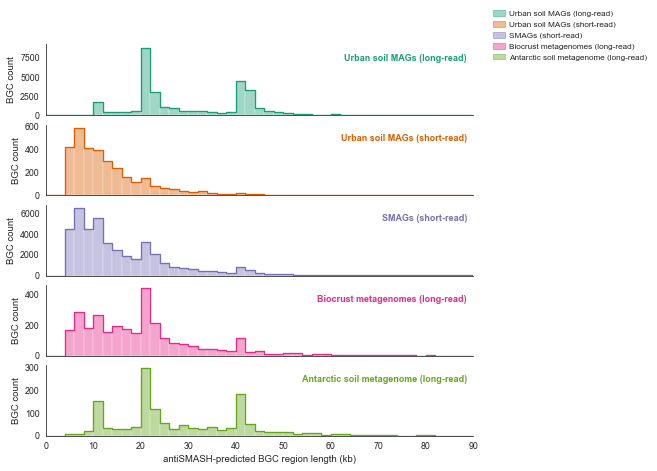

In [7]:
fig, axes = plt.subplots(
    nrows=len(panels),
    ncols=1,
    figsize=(8.8, 7.2),
    sharex=True,
    sharey=False,
    gridspec_kw={'hspace': 0.13},
)

for ax, (label, values, color) in zip(axes, panels):
    plot_data = pd.DataFrame({'length_kb': values})
    sns.histplot(
        data=plot_data,
        x='length_kb',
        binwidth=2,
        binrange=(0, 90),
        stat='count',
        color=color,
        alpha=0.42,
        edgecolor='white',
        linewidth=0.25,
        ax=ax,
    )
    sns.histplot(
        data=plot_data,
        x='length_kb',
        binwidth=2,
        binrange=(0, 90),
        stat='count',
        element='step',
        fill=False,
        color=color,
        linewidth=1.35,
        ax=ax,
    )
    style_axis(ax)
    ax.text(
        0.985,
        0.80,
        label,
        transform=ax.transAxes,
        ha='right',
        va='center',
        fontsize=9,
        color=color,
        fontweight='bold',
    )

for ax in axes[:-1]:
    ax.tick_params(axis='x', labelbottom=False)
    ax.set_xlabel('')
axes[-1].set_xlabel(
    'antiSMASH-predicted BGC region length (kb)',
    fontsize=9.6,
)

handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor=color,
        edgecolor=color,
        alpha=0.42,
    )
    for _, _, color in panels
]
labels = [label for label, _, _ in panels]
fig.legend(
    handles,
    labels,
    loc='upper left',
    bbox_to_anchor=(0.82, 0.96),
    frameon=False,
    fontsize=8.2,
    handlelength=1.4,
    handletextpad=0.55,
)
fig.subplots_adjust(right=0.80)

plt.show()

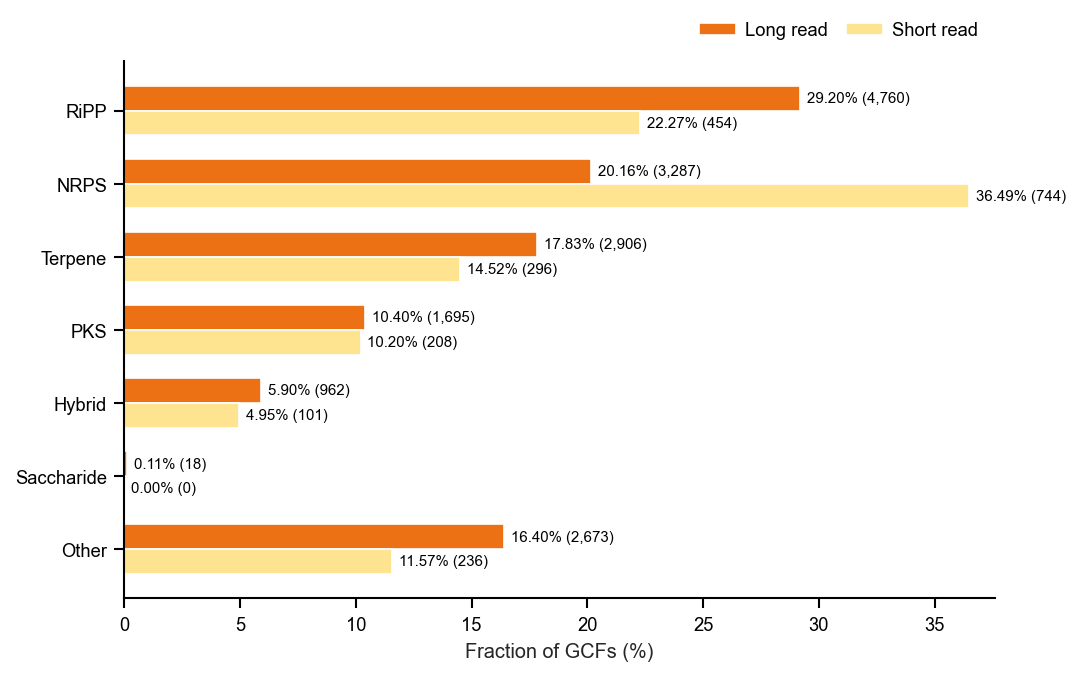

In [11]:
base_dir = Path('../pre-calculated_data/')

bgc_columns = [
    'GBK', 'type', 'category', 'start', 'end', 'length', 'mag', 'gtdb',
    'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species',
]


def broad_category(value):
    if pd.isna(value):
        return 'Unclassified'
    value = str(value)
    if '.' in value:
        return 'Hybrid'
    mapping = {
        'nrps': 'NRPS',
        'pks': 'PKS',
        'ripp': 'RiPP',
        'terpene': 'Terpene',
        'saccharide': 'Saccharide',
        'other': 'Other',
    }
    return mapping.get(value.lower(), value)


def short_read_join_key(values, clustered=False):
    values = values.astype(str)
    if clustered:
        contig = (
            values.str.replace(r'\.region\d+$', '', regex=True)
            .str.replace('.fa.gz_', '.', regex=False)
        )
        region_number = values.str.extract(r'\.region(\d+)$', expand=False)
    else:
        contig = values.str.replace(r'\.region\d+\.\d+$', '', regex=True)
        region_number = values.str.extract(
            r'\.region\d+\.(\d+)$', expand=False
        )
    if region_number.isna().any():
        bad = values[region_number.isna()].head().tolist()
        raise ValueError(f'Could not parse short-read region identifiers: {bad}')
    return contig + '#' + region_number.astype(int).astype(str)


def load_gcf_categories(source, bgc_file, cluster_file, short_read=False):
    bgc = pd.read_csv(
        base_dir / bgc_file,
        sep='\t',
        header=None,
        names=bgc_columns,
    )
    cluster = pd.read_csv(base_dir / cluster_file, sep='\t')

    if short_read:
        bgc['_join_key'] = short_read_join_key(bgc['GBK'])
        cluster['_join_key'] = short_read_join_key(
            cluster['GBK'], clustered=True
        )
        if bgc['_join_key'].duplicated().any():
            raise ValueError('Duplicate normalized identifiers in short-read BGC table')
        if cluster['_join_key'].duplicated().any():
            raise ValueError('Duplicate normalized identifiers in short-read cluster table')
        merged = bgc.merge(
            cluster[['_join_key', 'Family']],
            on='_join_key',
            how='inner',
            validate='one_to_one',
        )
    else:
        merged = bgc.merge(
            cluster[['GBK', 'Family']],
            on='GBK',
            how='inner',
            validate='one_to_one',
        )

    if len(merged) != len(bgc) or len(merged) != len(cluster):
        raise ValueError(
            f'{source}: incomplete BGC-cluster match '
            f'(BGC={len(bgc):,}, cluster={len(cluster):,}, matched={len(merged):,})'
        )

    merged['broad_category'] = merged['category'].map(broad_category)
    gcf_category = merged.groupby('Family')['broad_category'].agg(
        lambda values: values.iloc[0]
        if values.nunique(dropna=False) == 1
        else 'Hybrid'
    )
    gcf = gcf_category.rename('category').reset_index()
    gcf['Source'] = source
    return gcf, merged


long_gcf, long_bgc_cluster = load_gcf_categories(
    'Long read',
    'bgc_region_len_gtdb.tsv',
    'mix_clustering_c0.3.tsv',
)
short_gcf, short_bgc_cluster = load_gcf_categories(
    'Short read',
    'short_read_bgc_region_len_gtdb.tsv',
    'mix_clustering_c0.3_sr.tsv',
    short_read=True,
)

gcf_compare = pd.concat([long_gcf, short_gcf], ignore_index=True)
source_order = ['Long read', 'Short read']
gcf_category_counts = pd.crosstab(
    gcf_compare['category'], gcf_compare['Source']
).reindex(columns=source_order, fill_value=0)
gcf_category_percent = (
    gcf_category_counts.div(gcf_category_counts.sum(axis=0), axis=1) * 100
)

other_label = 'Other'
ordered_categories = (
    gcf_category_percent.drop(index=other_label, errors='ignore')
    .sort_values('Long read', ascending=False)
    .index.tolist()
)
if other_label in gcf_category_percent.index:
    ordered_categories.append(other_label)

gcf_category_counts = gcf_category_counts.loc[ordered_categories]
gcf_category_percent = gcf_category_percent.loc[ordered_categories]

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.linewidth'] = 0.9
mpl.rcParams['xtick.major.width'] = 0.9
mpl.rcParams['ytick.major.width'] = 0.9
mpl.rcParams['xtick.major.size'] = 4
mpl.rcParams['ytick.major.size'] = 4
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.direction'] = 'out'
mpl.rcParams['figure.dpi'] = 150

sns.set_theme(style='ticks', context='paper')
sns.set_style({
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.grid': False,
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
})

source_palette = {
    'Long read': '#ec7014ff',
    'Short read': '#fee391ff',
}

fig, ax = plt.subplots(figsize=(7.3, 4.6))
bar_height = 0.34
y_positions = np.arange(len(gcf_category_percent))
bar_specs = [
    ('Long read', -bar_height / 2),
    ('Short read', bar_height / 2),
]
for source, offset in bar_specs:
    ax.barh(
        y_positions + offset,
        gcf_category_percent[source],
        height=bar_height,
        color=source_palette[source],
        label=source,
    )

xmax = gcf_category_percent.to_numpy().max() * 1.03
ax.set_xlim(0, xmax)
for source, offset in bar_specs:
    for y, category_name in zip(y_positions, gcf_category_percent.index):
        percent = gcf_category_percent.loc[category_name, source]
        count = int(gcf_category_counts.loc[category_name, source])
        ax.text(
            percent + xmax * 0.008,
            y + offset,
            f'{percent:.2f}% ({count:,})',
            va='center',
            ha='left',
            fontsize=7.2,
            clip_on=False,
        )

ax.set_yticks(y_positions)
ax.set_yticklabels(gcf_category_percent.index)
ax.invert_yaxis()
ax.set_xlabel('Fraction of GCFs (%)')
ax.set_ylabel('')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(
    frameon=False,
    loc='lower right',
    bbox_to_anchor=(1.0, 1.01),
    ncol=2,
    columnspacing=1.0,
    handletextpad=0.5,
)
plt.tight_layout()
plt.show()


In [2]:
df = pd.read_csv(r'../pre-calculated_data/bgc_region_len_gtdb.tsv',sep='\t',header=None,names=['GBK','type','category','start','end','length','mag','gtdb','domain','phylum','class','order','family','genus','species'])
df

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__


In [139]:
cluster = pd.read_csv(r'../pre-calculated_data/mix_clustering_c0.3.tsv',sep='\t')
cluster

,Record,GBK,Record_Type,Record_Number,CC,Family
0,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001
1,snj20_SemiBin_27.fa_contig_27097_polypolish.re...,snj20_SemiBin_27.fa_contig_27097_polypolish.re...,region,2,5,FAM_00001
2,snj15_SemiBin_80.fa_contig_81334_polypolish.re...,snj15_SemiBin_80.fa_contig_81334_polypolish.re...,region,1,5,FAM_00001
3,sample7_SemiBin_122.fa_contig_6681_polypolish....,sample7_SemiBin_122.fa_contig_6681_polypolish....,region,1,5,FAM_00001
4,snj09_SemiBin_99.fa_contig_12697_polypolish.re...,snj09_SemiBin_99.fa_contig_12697_polypolish.re...,region,4,5,FAM_00001
...,...,...,...,...,...,...
31629,sample7_SemiBin_145.fa_contig_75202_polypolish...,sample7_SemiBin_145.fa_contig_75202_polypolish...,region,1,147608,FAM_16297
31630,sample6_SemiBin_10.fa_contig_2173_polypolish.r...,sample6_SemiBin_10.fa_contig_2173_polypolish.r...,region,1,147628,FAM_16298
31631,snj13_SemiBin_95.fa_contig_23682_polypolish.re...,snj13_SemiBin_95.fa_contig_23682_polypolish.re...,region,1,147636,FAM_16299
31632,sample16_SemiBin_99.fa_contig_98589_polypolish...,sample16_SemiBin_99.fa_contig_98589_polypolish...,region,1,147640,FAM_16300


In [140]:
bgc_cluster = df.merge(cluster,on='GBK')
bgc_cluster

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,region,1,1,FAM_03770
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595,sample5_SemiBin_96.fa_contig_47116_polypolish....,region,1,13,FAM_03772
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__,sample27_SemiBin_67.fa_contig_139761_polypolis...,region,2,17,FAM_03773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__,sample6_SemiBin_68.fa_contig_33264_polypolish....,region,1,147644,FAM_16301
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,region,1,14063,FAM_01644
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__,sample21_SemiBin_26.fa_contig_74783_polypolish...,region,1,5836,FAM_01007
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,region,2,37,FAM_00021


In [141]:
bgc_cluster['category'] = bgc_cluster['category'].apply(lambda x: 'hybrid' if isinstance(x, str) and '.' in x else x)
bgc_cluster

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,region,1,1,FAM_03770
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595,sample5_SemiBin_96.fa_contig_47116_polypolish....,region,1,13,FAM_03772
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__,sample27_SemiBin_67.fa_contig_139761_polypolis...,region,2,17,FAM_03773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__,sample6_SemiBin_68.fa_contig_33264_polypolish....,region,1,147644,FAM_16301
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,region,1,14063,FAM_01644
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__,sample21_SemiBin_26.fa_contig_74783_polypolish...,region,1,5836,FAM_01007
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,region,2,37,FAM_00021


In [142]:
family_category_counts = bgc_cluster.groupby('Family')['category'].transform('nunique')
family_category_counts

0        1
1        1
2        1
3        1
4        1
        ..
31629    1
31630    1
31631    1
31632    1
31633    1
Name: category, Length: 31634, dtype: int64

In [143]:
bgc_cluster.loc[family_category_counts > 1, 'category'] = 'hybrid'
bgc_cluster

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,region,1,1,FAM_03770
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595,sample5_SemiBin_96.fa_contig_47116_polypolish....,region,1,13,FAM_03772
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__,sample27_SemiBin_67.fa_contig_139761_polypolis...,region,2,17,FAM_03773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__,sample6_SemiBin_68.fa_contig_33264_polypolish....,region,1,147644,FAM_16301
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,region,1,14063,FAM_01644
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__,sample21_SemiBin_26.fa_contig_74783_polypolish...,region,1,5836,FAM_01007
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,region,2,37,FAM_00021


In [144]:
family_phylum_counts = bgc_cluster.groupby(['Family', 'phylum']).size().reset_index(name='count')
top_phylum_per_family = family_phylum_counts.loc[
    family_phylum_counts.groupby('Family')['count'].idxmax()
]
phylum_map = dict(zip(top_phylum_per_family['Family'], top_phylum_per_family['phylum']))
bgc_cluster['phylum_unified'] = bgc_cluster['Family'].map(phylum_map)
bgc_cluster

,GBK,type,category,start,end,length,mag,gtdb,domain,phylum,...,order,family,genus,species,Record,Record_Type,Record_Number,CC,Family,phylum_unified
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,...,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,region,1,1,FAM_03770,p__Pseudomonadota
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,...,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,region,3,5,FAM_00001,p__Methylomirabilota
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,...,o__RBC074,f__RBC074,g__JAHBSF01,s__,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,region,1,9,FAM_03771,p__Acidobacteriota
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,...,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595,sample5_SemiBin_96.fa_contig_47116_polypolish....,region,1,13,FAM_03772,p__Nitrospirota
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,...,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__,sample27_SemiBin_67.fa_contig_139761_polypolis...,region,2,17,FAM_03773,p__Pseudomonadota
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,...,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__,sample6_SemiBin_68.fa_contig_33264_polypolish....,region,1,147644,FAM_16301,p__Myxococcota
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,...,o__Polarisedimenticolales,f__DASUFT01,g__,s__,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,region,1,14063,FAM_01644,p__Acidobacteriota
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,...,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__,sample21_SemiBin_26.fa_contig_74783_polypolish...,region,1,5836,FAM_01007,p__Methylomirabilota
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,...,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,region,2,37,FAM_00021,p__Pseudomonadota


In [145]:
phylum_family_counts = bgc_cluster.groupby('phylum_unified')['Family'].nunique().sort_values(ascending=False).reset_index().head(15).sort_values(by='Family',ascending=True).set_index('phylum_unified')
phylum_family_counts

,Family
phylum_unified,
p__Tectomicrobia,87
p__Nitrospirota,194
p__Myxococcota_A,220
p__Eisenbacteria,221
p__Chloroflexota,455
p__Bacteroidota,473
p__Verrucomicrobiota,515
p__Planctomycetota,672
p__Actinomycetota,716


(array([   0., 2000., 4000., 6000.]),
 [Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')])

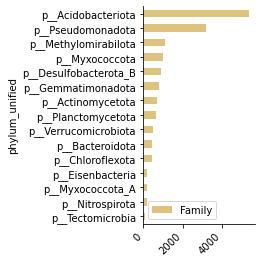

In [146]:
fig, ax = plt.subplots(figsize=(2, 4))
phylum_family_counts.plot(kind='barh', ax=ax,color='#dfc27d')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(rotation=45, ha='right')

In [147]:
gcf_unique_df = bgc_cluster[['Family', 'category', 'phylum_unified']].drop_duplicates()
gcf_unique_df

,Family,category,phylum_unified
0,FAM_03770,RiPP,p__Pseudomonadota
1,FAM_00001,other,p__Methylomirabilota
2,FAM_03771,terpene,p__Acidobacteriota
3,FAM_03772,RiPP,p__Nitrospirota
4,FAM_03773,other,p__Pseudomonadota
...,...,...,...
31622,FAM_16297,terpene,p__Acidobacteriota
31625,FAM_16298,NRPS,p__Actinomycetota
31627,FAM_16299,NRPS,p__Bacteroidota
31628,FAM_16300,PKS,p__Planctomycetota


In [148]:
counts = gcf_unique_df.groupby(['phylum_unified', 'category']).size().reset_index(name='count')
pivot_df = counts.pivot(index='phylum_unified', columns='category', values='count').fillna(0)
pivot_df

category,NRPS,PKS,RiPP,hybrid,other,saccharide,terpene
phylum_unified,,,,,,,
p__ARS69,1.0,10.0,3.0,0.0,0.0,0.0,7.0
p__Acidobacteriota,1335.0,472.0,1975.0,405.0,394.0,8.0,762.0
p__Actinomycetota,93.0,77.0,201.0,51.0,167.0,4.0,123.0
p__Armatimonadota,0.0,0.0,4.0,0.0,2.0,0.0,1.0
p__Bacteroidota,39.0,113.0,51.0,23.0,110.0,0.0,137.0
p__Bacteroidota_A,0.0,3.0,2.0,2.0,1.0,0.0,20.0
p__Bdellovibrionota,0.0,0.0,2.0,0.0,1.0,0.0,1.0
p__Bdellovibrionota_G,0.0,1.0,1.0,0.0,0.0,0.0,2.0
p__Chlamydiota,1.0,1.0,2.0,0.0,0.0,0.0,0.0


In [149]:
pivot_df['total'] = pivot_df.sum(axis=1)

pivot_top15 = pivot_df.sort_values('total', ascending=False).head(15)
pivot_top15

category,NRPS,PKS,RiPP,hybrid,other,saccharide,terpene,total
phylum_unified,,,,,,,,
p__Acidobacteriota,1335.0,472.0,1975.0,405.0,394.0,8.0,762.0,5351.0
p__Pseudomonadota,526.0,261.0,862.0,145.0,906.0,2.0,452.0,3154.0
p__Methylomirabilota,260.0,100.0,290.0,44.0,247.0,0.0,153.0,1094.0
p__Myxococcota,213.0,175.0,276.0,62.0,159.0,0.0,137.0,1022.0
p__Desulfobacterota_B,294.0,36.0,192.0,61.0,178.0,1.0,133.0,895.0
p__Gemmatimonadota,147.0,16.0,390.0,56.0,31.0,1.0,147.0,788.0
p__Actinomycetota,93.0,77.0,201.0,51.0,167.0,4.0,123.0,716.0
p__Planctomycetota,101.0,159.0,83.0,35.0,93.0,0.0,201.0,672.0
p__Verrucomicrobiota,85.0,45.0,28.0,20.0,88.0,0.0,249.0,515.0


In [150]:
pivot_top15 = pivot_top15.sort_values('total', ascending=True)

pivot_top15 = pivot_top15.drop(columns='total')

pivot_percent = pivot_top15.div(pivot_top15.sum(axis=1), axis=0)
pivot_percent

category,NRPS,PKS,RiPP,hybrid,other,saccharide,terpene
phylum_unified,,,,,,,
p__Tectomicrobia,0.252874,0.045977,0.287356,0.080460,0.218391,0.000000,0.114943
p__Nitrospirota,0.072165,0.005155,0.298969,0.046392,0.345361,0.000000,0.231959
p__Myxococcota_A,0.081818,0.154545,0.222727,0.059091,0.336364,0.000000,0.145455
p__Eisenbacteria,0.099548,0.271493,0.190045,0.018100,0.067873,0.000000,0.352941
p__Chloroflexota,0.158242,0.138462,0.136264,0.041758,0.175824,0.004396,0.345055
p__Bacteroidota,0.082452,0.238901,0.107822,0.048626,0.232558,0.000000,0.289641
p__Verrucomicrobiota,0.165049,0.087379,0.054369,0.038835,0.170874,0.000000,0.483495
p__Planctomycetota,0.150298,0.236607,0.123512,0.052083,0.138393,0.000000,0.299107
p__Actinomycetota,0.129888,0.107542,0.280726,0.071229,0.233240,0.005587,0.171788


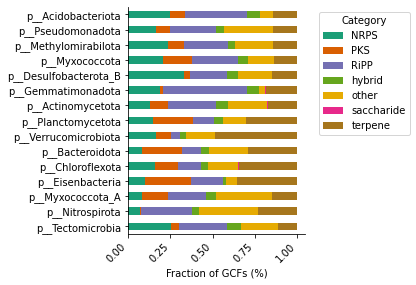

In [65]:
fig, ax = plt.subplots(figsize=(6, 4))
custom_colors = ['#1b9e77', '#d95f02', '#7570b3', '#66a61e', '#e6ab02', '#e7298a','#a6761d']
pivot_percent.plot(kind='barh', stacked=True,color=custom_colors,ax=ax)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xlabel('Fraction of GCFs (%)')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()